In [19]:
import numpy as np
from tqdm import tqdm
import scipy.linalg as la
import numpy.linalg as npla

import torch
import normflows as nf

import pid
import pid.utils.distributions as dist
from pid.utils.generate import sample_mult_poisson
from pid.utils.custom_flow import CartesianProductFlow

In [20]:
def get_params():
    lamda_m = np.array([2., 2.])
    lamda_x = np.array([1.,])      # Noise to be added to X: shape (d_X,)
    lamda_y = np.array([1.,])

    w_x1_vals = np.arange(11) / 10
    w_x2 = 0.5
    w_y1 = 0.5
    w_y2 = 0.5

    return lamda_m, lamda_x, lamda_y, w_x1_vals, w_x2, w_y1, w_y2

In [21]:
def objective(sig, hx, hy, dm, dx, dy, reg):
    S = (1 + reg) * np.eye(dx) - sig @ sig.T
    B = hx - sig @ hy
    obj = 0.5 / np.log(2) * npla.slogdet(
        np.eye(dm) + hy.T @ hy + B.T @ la.solve(S, B)
    )[1]
    return obj

In [22]:
num_samples=10000
flow_iter=1000
n_flows=3

enable_cuda=True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
print(f"Using device: {device}")

lamda_m, lamda_x, lamda_y, w_x1_vals, w_x2, w_y1, w_y2 = get_params()
dm = lamda_m.size  # Number of dimensions of M
dx = lamda_x.size  # Number of dimensions of X
dy = lamda_y.size  # Number of dimensions of Y

Using device: cuda


In [23]:
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

def train_flow(x_data, y_data, m_data, n_epochs=100, batch_size=64, lr=2e-4):
    # Initialize model
    dim_x, dim_y, dim_m = x_data.shape[1], y_data.shape[1], m_data.shape[1]
    flow = CartesianProductFlow(dim_m, dim_x, dim_y, n_flows)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr)
    
    # Create dataset
    print(x_data.shape, y_data.shape, m_data.shape)
    dataset = TensorDataset(torch.tensor(x_data,dtype=torch.float32), torch.tensor(y_data,dtype=torch.float32), torch.tensor(m_data,dtype=torch.float32))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    losses = []
    
    for epoch in tqdm(range(n_epochs)):
        epoch_losses = []
        
        for x_batch, y_batch, m_batch in dataloader:
            optimizer.zero_grad()
            
            # Forward pass
            z_m, z_x, z_y, log_det = flow(m_batch, x_batch, y_batch)
            
            # Compute loss
            loss = flow.compute_loss(z_m, z_x, z_y, log_det)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
        
        avg_loss = sum(epoch_losses) / len(epoch_losses)
        losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}")
            
            # Print learned parameters
            print(f"Learned mean: {flow.mean.data}")
            print(f"Learned covariance:\n{flow.get_covariance().data}")

            if epoch > 30:
              ret = pid.utils.whiten(flow.get_covariance().detach().cpu().numpy(), dm, dx, dy, ret_channel_params=True)
              sig_mxy, hx, hy, hxy, sigxy = ret
              sig, obj, _ = pid.optimizers.thinpid_exact_pid_minimizer(hx, hy, ret_obj=True, reg=1e-7)
              union_info = objective(sig, hx, hy, dm, dx, dy, reg=1e-7)
              print(f"Union information:{union_info}")
    
    # Plot loss curve
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.show()
    
    return flow, losses

(10000, 2) (10000, 1) (10000, 1)


  1%|          | 10/1000 [00:04<06:58,  2.36it/s]

Epoch 10/1000, Loss: 347.2806
Learned mean: tensor([0.0374, 0.0304, 0.0299, 0.0329])
Learned covariance:
tensor([[0.0200, 0.0067, 0.0065, 0.0056],
        [0.0067, 0.0180, 0.0060, 0.0057],
        [0.0065, 0.0060, 0.0179, 0.0038],
        [0.0056, 0.0057, 0.0038, 0.0182]])


  2%|▏         | 20/1000 [00:08<07:34,  2.16it/s]

Epoch 20/1000, Loss: 215.8008
Learned mean: tensor([0.0650, 0.0518, 0.0518, 0.0564])
Learned covariance:
tensor([[0.0280, 0.0109, 0.0106, 0.0081],
        [0.0109, 0.0243, 0.0120, 0.0085],
        [0.0106, 0.0120, 0.0241, 0.0057],
        [0.0081, 0.0085, 0.0057, 0.0241]])


...

Epoch 980/1000, Loss: -2.9930
Learned mean: tensor([0.8418, 0.4768, 0.3740, 0.8412])
Learned covariance:
tensor([[0.2507, 0.0764, 0.0488, 0.0359],
        [0.0764, 0.1415, 0.0837, 0.0365],
        [0.0488, 0.0837, 0.1051, 0.0068],
        [0.0359, 0.0365, 0.0068, 0.2260]])
Union information:0.46421640210552795


 99%|█████████▉| 990/1000 [07:22<00:04,  2.19it/s]

Epoch 990/1000, Loss: -3.0478
Learned mean: tensor([0.8498, 0.4798, 0.3757, 0.8433])
Learned covariance:
tensor([[0.2550, 0.0765, 0.0490, 0.0368],
        [0.0765, 0.1409, 0.0817, 0.0374],
        [0.0490, 0.0817, 0.1087, 0.0065],
        [0.0368, 0.0374, 0.0065, 0.2299]])
Union information:0.4176720103523089


100%|██████████| 1000/1000 [07:26<00:00,  2.24it/s]

Epoch 1000/1000, Loss: -3.5227
Learned mean: tensor([0.8608, 0.4790, 0.3787, 0.8521])
Learned covariance:
tensor([[0.2570, 0.0780, 0.0501, 0.0369],
        [0.0780, 0.1429, 0.0838, 0.0379],
        [0.0501, 0.0838, 0.1095, 0.0075],
        [0.0369, 0.0379, 0.0075, 0.2340]])
Union information:0.4338663221926073


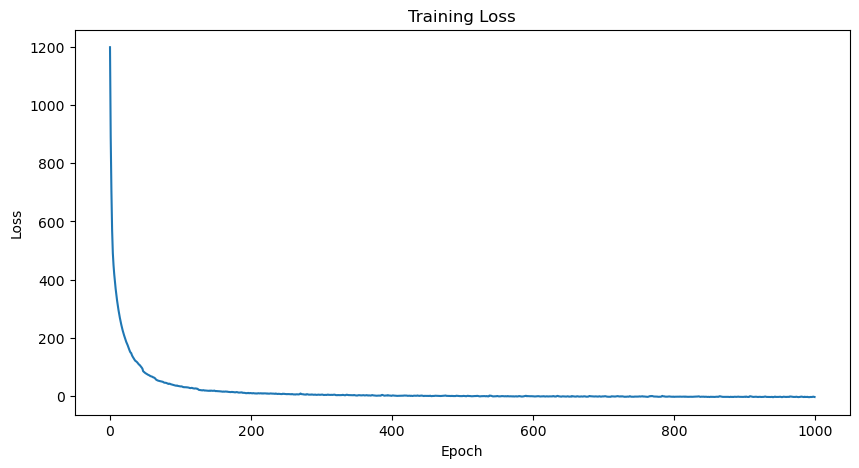

In [24]:
w_x1 = w_x1_vals[0]
w_x = np.array([[w_x1, w_x2]])  # Binomial thinning weights: shape (dx, dm)
w_y = np.array([[w_y1, w_y2]])
m, x, y = sample_mult_poisson(num_samples, lamda_m, w_x, w_y, lamda_x, lamda_y)  # Shape: (d, n)


trained_flow, training_losses = train_flow(m.T, x.T, y.T, n_epochs=1000, batch_size=1000, lr=5e-4)